In [1]:
# importing necessary library
import os
import pandas as pd
import numpy as np
#import matpoly lib
import matplotlib.pyplot as plt
import seaborn as sns

#import Scikit learn and some other ml libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.svm import SVC

In [2]:
# Load test and train dataset
df_test = pd.read_csv("test.csv")
df_train = pd.read_csv("train.csv")

In [3]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  str    
 1   Date of Joining       22750 non-null  str    
 2   Gender                22750 non-null  str    
 3   Company Type          22750 non-null  str    
 4   WFH Setup Available   22750 non-null  str    
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), str(5)
memory usage: 1.6 MB


In [4]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 12250 entries, 0 to 12249
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           12250 non-null  str    
 1   Date of Joining       12250 non-null  str    
 2   Gender                12250 non-null  str    
 3   Company Type          12250 non-null  str    
 4   WFH Setup Available   12250 non-null  str    
 5   Designation           12250 non-null  float64
 6   Resource Allocation   12250 non-null  float64
 7   Mental Fatigue Score  12250 non-null  float64
dtypes: float64(3), str(5)
memory usage: 765.8 KB


In [5]:
df_train.head(10) # Load and test the train dataset

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52
5,fffe3300350037003500,2008-11-26,Male,Product,Yes,2.0,4.0,3.6,0.29
6,fffe33003300340039003100,2008-01-02,Female,Service,No,3.0,6.0,7.9,0.62
7,fffe32003600320037003400,2008-10-31,Female,Service,Yes,2.0,4.0,4.4,0.33
8,fffe32003200300034003700,2008-12-27,Female,Service,No,3.0,6.0,NaN,0.56
9,fffe31003600320030003200,2008-03-09,Female,Product,No,3.0,6.0,NaN,0.67


In [6]:
df_train = df_train.fillna('N/A') # fill na with "N/A"

df_train[22730:22750]
#counting numbers of N/A.
null_count = (df_train.isnull().sum().sum() + df_train.eq('N/A').sum().sum())
print('The total number of N/A is: ',null_count)

#counting percentage of N/A.
null_count = (df_train.isnull().sum().sum() + df_train.eq('N/A').sum().sum())
print(f'The Percentage of N/A is: ,{((null_count/len(df_train))*100)}')

# assuming i want to drop based on the 'unknown' i renamed it to'
df = df_train[df_train.ne('N/A').all(axis=1)] 

The total number of N/A is:  4622
The Percentage of N/A is: ,20.316483516483515


In [7]:
df = df.drop_duplicates() # drop duplicate
df.drop('Employee ID',  axis=1, inplace=True) # dropping the employee ID column
df.info()

<class 'pandas.DataFrame'>
Index: 18590 entries, 0 to 22749
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date of Joining       18590 non-null  str    
 1   Gender                18590 non-null  str    
 2   Company Type          18590 non-null  str    
 3   WFH Setup Available   18590 non-null  str    
 4   Designation           18590 non-null  float64
 5   Resource Allocation   18590 non-null  object 
 6   Mental Fatigue Score  18590 non-null  object 
 7   Burn Rate             18590 non-null  object 
dtypes: float64(1), object(3), str(4)
memory usage: 1.3+ MB


In [8]:
# Convert the Date of Joining column to datetime
df['Date of Joining'] = pd.to_datetime(df['Date of Joining'], errors='coerce')

# Cring the  a new column 'tenure' in ye()
df['tenure'] = (pd.Timestamp('today') - df['Date of Joining']).dt.days//365   #year

In [9]:
# for correlaton to be applied datatpes of independent features against dependent needs to be connverted (encode)
df['Resource Allocation'] = df['Resource Allocation']
df['Mental Fatigue Score'] = df['Mental Fatigue Score']
df['Burn Rate'] = df['Burn Rate']

# Encode: Female = 0, Male = 1 (or vice versa)
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})


# Convert to proper numeric values (invalid entries become NaN)
df['Resource Allocation'] = pd.to_numeric(df['Resource Allocation'], errors='coerce')
df['Mental Fatigue Score'] = pd.to_numeric(df['Mental Fatigue Score'], errors='coerce')
df['Burn Rate'] = pd.to_numeric(df['Burn Rate'], errors='coerce')
df['Gender'] = pd.to_numeric(df['Gender'], errors='coerce')

print(df.dtypes)

Date of Joining         datetime64[us]
Gender                           int64
Company Type                       str
WFH Setup Available                str
Designation                    float64
Resource Allocation            float64
Mental Fatigue Score           float64
Burn Rate                      float64
tenure                           int64
dtype: object


In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist() # numeric_cols
correlations = df[numeric_cols].corr()['Burn Rate'].sort_values(ascending=False) # Compute correlation with Burn Rate
print(correlations)

Burn Rate               1.000000
Mental Fatigue Score    0.944389
Resource Allocation     0.855005
Designation             0.736412
Gender                  0.156577
tenure                 -0.004288
Name: Burn Rate, dtype: float64


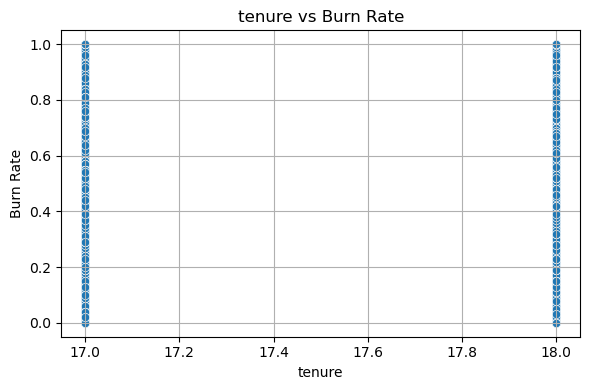

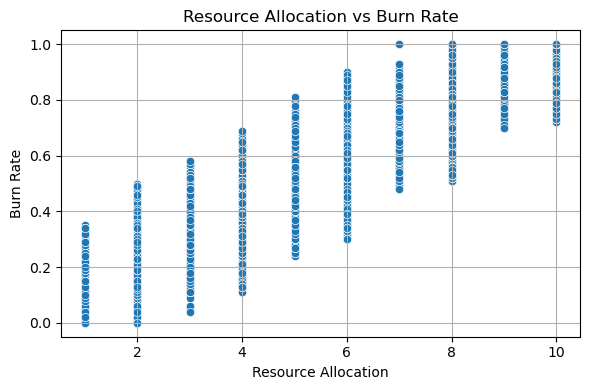

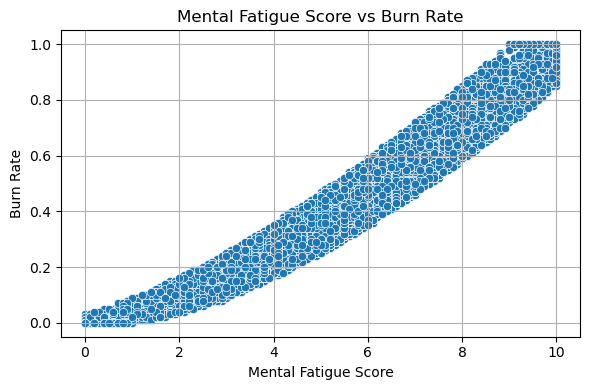

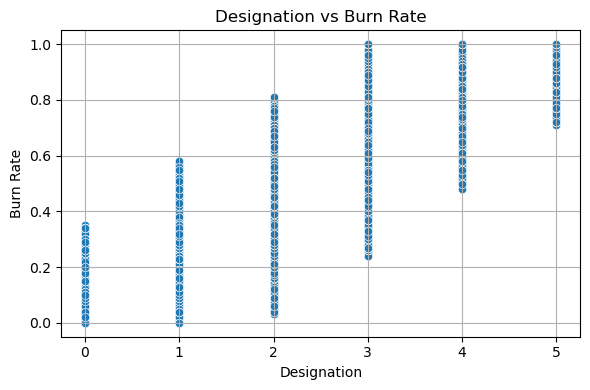

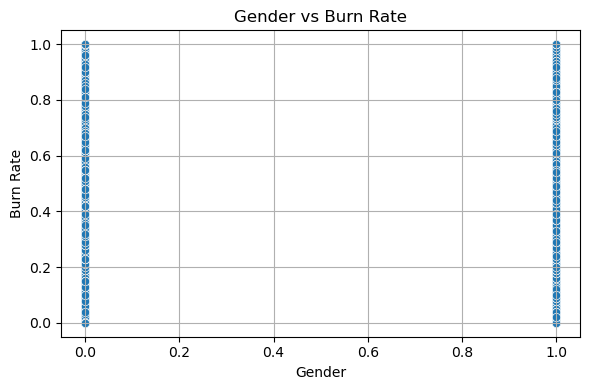

In [11]:
features_to_plot = ['tenure', 'Resource Allocation', 'Mental Fatigue Score', 'Designation','Gender']

for feature in features_to_plot:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=feature, y='Burn Rate', data=df)
    plt.title(f'{feature} vs Burn Rate')
    plt.xlabel(feature)
    plt.ylabel('Burn Rate')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

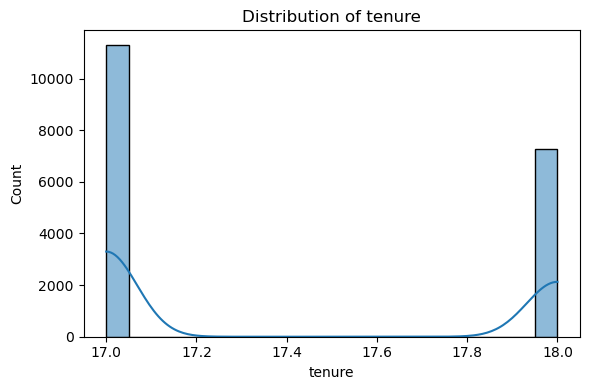

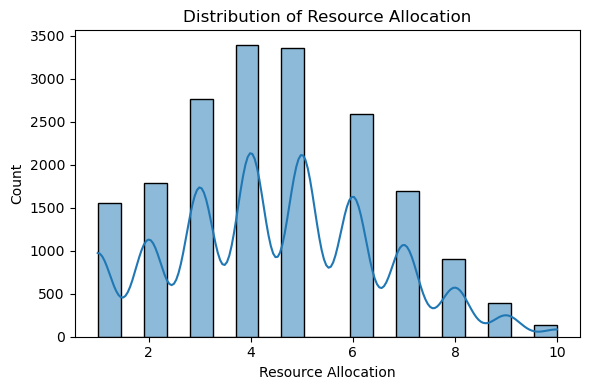

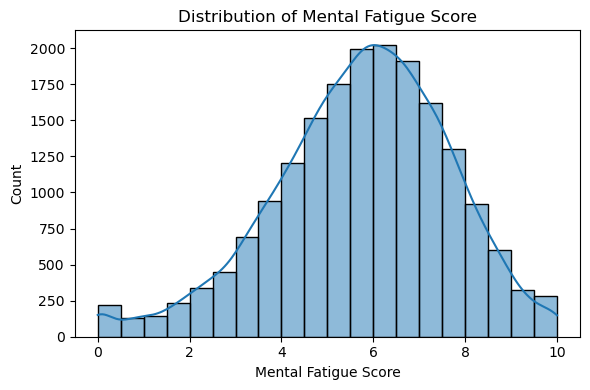

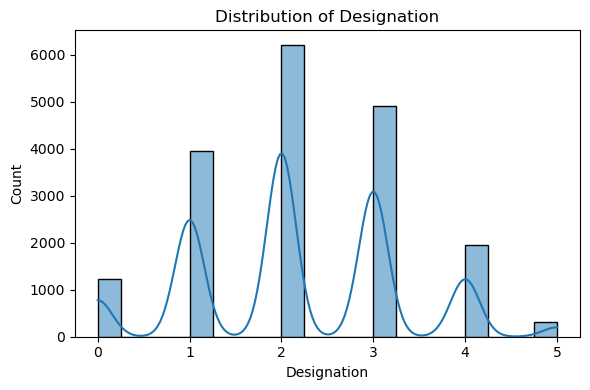

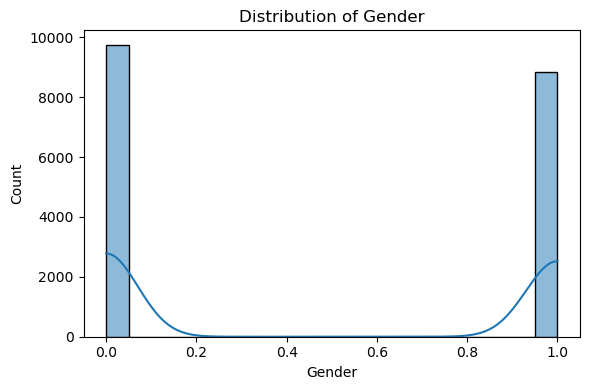

In [12]:
# histplot visual
for feature in features_to_plot:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[feature], kde=True, bins=20)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()

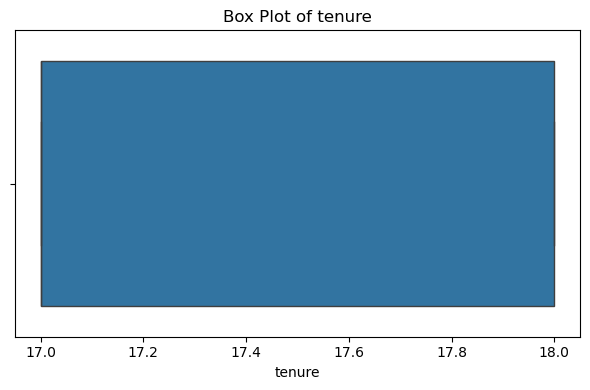

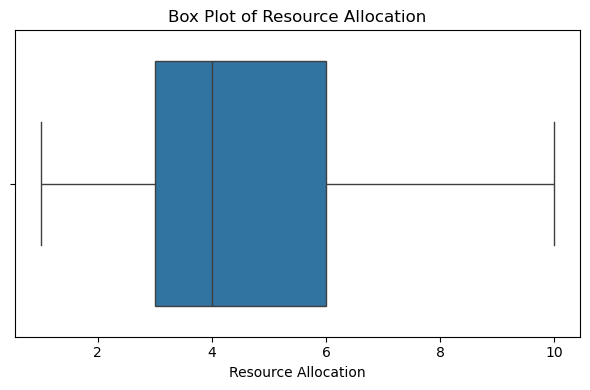

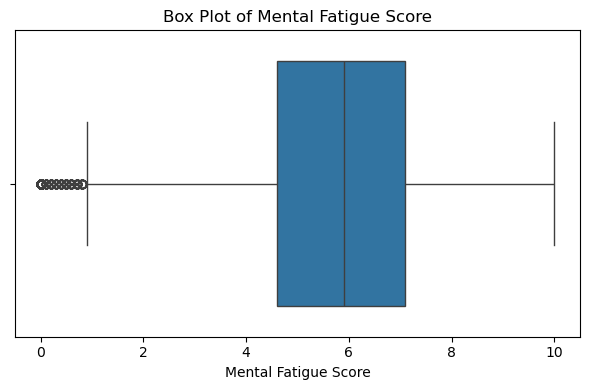

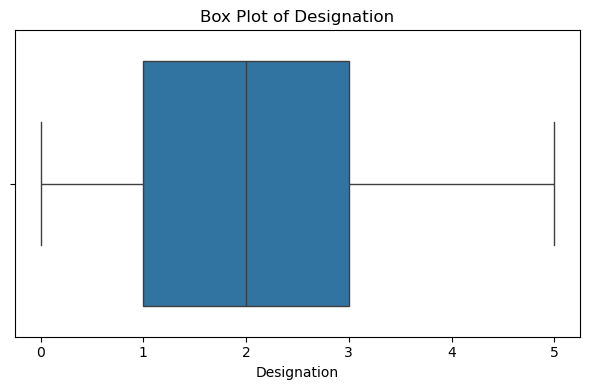

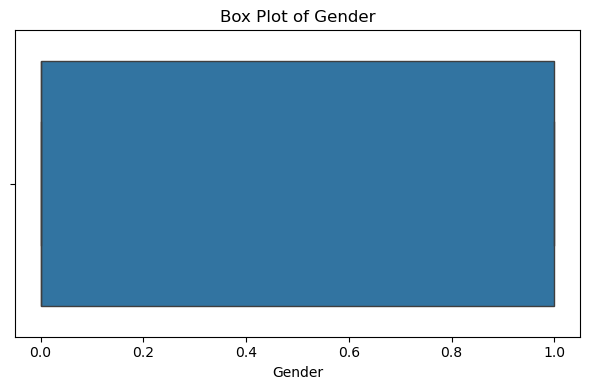

In [13]:
# Boxplot visual
for feature in features_to_plot:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()

In [14]:
# performing on hot_encoding on company type, WFH, and Gender.
# importing the required library
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

columns_for_one_hot = ['Gender','WFH Setup Available','Company Type'] # one hot encoding on this columns observation (no order)

# Initialize OneHotEncoder and create object
one_hot_encoder = OneHotEncoder(sparse_output=False)  # Ensure output is a dense array
# fit and transform
one_hot_encoded_data = one_hot_encoder.fit_transform(df[columns_for_one_hot])

encoded_data_df =pd.DataFrame(one_hot_encoded_data, columns=one_hot_encoder.get_feature_names_out()) # create new df with encoded data

df_one_hot = pd.concat([df.drop(columns_for_one_hot, axis=1),encoded_data_df], axis=1) # Combine back into the original dataframe (excuding the previous columns declared earlier)

In [15]:
# changing format
df_one_hot['Date of Joining']= pd.to_datetime(df_one_hot['Date of Joining'])

# calculating number of months since Date of Joining
df_one_hot['tenure'] = (pd.Timestamp('today') - df_one_hot['Date of Joining']).dt.days//365   # year

In [16]:
df= df_one_hot.dropna() # drop null value
df.head()

,Date of Joining,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,tenure,Gender_0,Gender_1,WFH Setup Available_No,WFH Setup Available_Yes,Company Type_Product,Company Type_Service
0,2008-09-30,2.0,3.0,3.8,0.16,17.0,1.0,0.0,1.0,0.0,0.0,1.0
1,2008-11-30,1.0,2.0,5.0,0.36,17.0,0.0,1.0,0.0,1.0,0.0,1.0
3,2008-11-03,1.0,1.0,2.6,0.20,17.0,1.0,0.0,1.0,0.0,0.0,1.0
4,2008-07-24,3.0,7.0,6.9,0.52,17.0,0.0,1.0,0.0,1.0,1.0,0.0
5,2008-11-26,2.0,4.0,3.6,0.29,17.0,1.0,0.0,1.0,0.0,0.0,1.0


In [17]:
df_one_hot.shape

(22015, 12)

In [18]:
X = df.drop(['Date of Joining', 'Burn Rate'], axis=1) # drop original column

In [19]:
# Normalize numeric values
scaler = StandardScaler()
column_to_norm = ['Designation','Resource Allocation','tenure']
df.loc[:, column_to_norm] = scaler.fit_transform(df[column_to_norm]) # use .loc to normalize and assign properly
df

,Date of Joining,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,tenure,Gender_0,Gender_1,WFH Setup Available_No,WFH Setup Available_Yes,Company Type_Product,Company Type_Service
0,2008-09-30,-0.159575,-0.726966,3.8,0.16,-0.803213,1.0,0.0,1.0,0.0,0.0,1.0
1,2008-11-30,-1.040839,-1.214860,5.0,0.36,-0.803213,0.0,1.0,0.0,1.0,0.0,1.0
3,2008-11-03,-1.040839,-1.702753,2.6,0.20,-0.803213,1.0,0.0,1.0,0.0,0.0,1.0
4,2008-07-24,0.721689,1.224608,6.9,0.52,-0.803213,0.0,1.0,0.0,1.0,1.0,0.0
5,2008-11-26,-0.159575,-0.239073,3.6,0.29,-0.803213,1.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
18585,2008-12-20,-0.159575,-0.239073,5.7,0.51,-0.803213,1.0,0.0,0.0,1.0,1.0,0.0
18586,2008-09-11,-0.159575,0.736715,7.2,0.72,-0.803213,0.0,1.0,1.0,0.0,1.0,0.0
18587,2008-10-08,0.721689,0.736715,9.0,0.77,-0.803213,1.0,0.0,0.0,1.0,1.0,0.0
18588,2008-11-29,-1.040839,-0.726966,3.4,0.15,-0.803213,1.0,0.0,1.0,0.0,0.0,1.0


In [20]:
y = df['Burn Rate']
y

0        0.16
1        0.36
3        0.20
4        0.52
5        0.29
         ... 
18585    0.51
18586    0.72
18587    0.77
18588    0.15
18589    0.24
Name: Burn Rate, Length: 15165, dtype: float64

In [21]:
# making use of thresholding
threshold= df['Burn Rate'].median()
y=np.where(df['Burn Rate']> threshold, 1, 0)
y

array([0, 0, 0, ..., 1, 0, 0], shape=(15165,))

In [22]:
# splitting data into training and testing
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [23]:
clf = LogisticRegression(max_iter=1000)

clf.fit(X_train, y_train)

# prediction on the test set
y_pred=clf.predict(X_test)

# Evaluate 
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification:", classification_report(y_test, y_pred))

Accuracy: 0.9057039235080778
Classification:               precision    recall  f1-score   support

           0       0.90      0.91      0.91      1519
           1       0.91      0.90      0.90      1514

    accuracy                           0.91      3033
   macro avg       0.91      0.91      0.91      3033
weighted avg       0.91      0.91      0.91      3033



In [24]:
# Random Forest

clf_rf = RandomForestClassifier(n_estimators=100)
clf_rf.fit(X_train, y_train)

# Prediction on the test set
y_pred_rf = clf_rf.predict(X_test)

# Evaluate 
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification:", classification_report(y_test, y_pred_rf))

Accuracy: 0.8977909660402242
Classification:               precision    recall  f1-score   support

           0       0.89      0.91      0.90      1519
           1       0.91      0.88      0.90      1514

    accuracy                           0.90      3033
   macro avg       0.90      0.90      0.90      3033
weighted avg       0.90      0.90      0.90      3033



In [25]:
# Support Vector Machine (SVM)
clf_svm = SVC(kernel='linear')
clf_svm.fit(X_train, y_train)
y_pred_svm = clf_svm.predict(X_test)

# Evaluate 
print("Accuracy:", accuracy_score(y_test, y_pred_svm ))
print("Classification:", classification_report(y_test, y_pred_svm ))

Accuracy: 0.9066930431915595
Classification:               precision    recall  f1-score   support

           0       0.90      0.92      0.91      1519
           1       0.92      0.89      0.91      1514

    accuracy                           0.91      3033
   macro avg       0.91      0.91      0.91      3033
weighted avg       0.91      0.91      0.91      3033



In [26]:
# Gradient Boosting
clf_gb = GradientBoostingClassifier(n_estimators=100)
clf_gb.fit(X_train, y_train)
y_pred_gb = clf_gb.predict(X_test)

# Evaluate 
print("Accuracy:", accuracy_score(y_test, y_pred_gb ))
print("Classification:", classification_report(y_test, y_pred_gb ))

Accuracy: 0.904055390702275
Classification:               precision    recall  f1-score   support

           0       0.88      0.94      0.91      1519
           1       0.93      0.87      0.90      1514

    accuracy                           0.90      3033
   macro avg       0.91      0.90      0.90      3033
weighted avg       0.91      0.90      0.90      3033



## Observation
- Burn Rate:                    1
- Mental Fatigue Score:    0.94438
- Resource Allocation:    0.85505
- Designation:            0.73612
- Gender:                 0.15577

## Model prediction
-  With Accuracy Prediction of mode of 0.90% shows a need for inprovement in the model prediction with logistic regression classifier.
- An increase in training will make model perform better